# Day 07：王者降临 —— 完整 Transformer 架构> 🚀 第十二周 · 注意力时代 · 第 7 天今天，我们要把所有拼图组合在一起，搭建完整的 **Transformer** 架构。从 2017 年至今，Transformer 已经成为深度学习最重要的架构——GPT、BERT、ViT、Stable Diffusion……它们的核心都是 Transformer。**今天的任务**：1. 搭建完整的 Transformer 模型2. 理解训练和推理的区别3. 用 Transformer 解决一个简单的翻译任务---

## 1. 历史剧场：2017 年，Attention Is All You Need2017 年 6 月，Google 的 8 位研究者发表了《Attention Is All You Need》。论文标题霸气外露——"你只需要注意力"。核心主张：> **RNN 的顺序计算是瓶颈。抛弃 RNN，只用注意力，就能做得更好。**结果：在英德翻译任务上，Transformer 以更少的训练时间达到了当时最好的效果。更重要的是，Transformer 开启了一个新时代：- **GPT 系列**（OpenAI）：只用 Transformer 的 Decoder- **BERT**（Google）：只用 Transformer 的 Encoder- **ViT**（Google）：把 Transformer 用在图像上- **DALL-E / Stable Diffusion**：用 Transformer 生成图像---

## 2. 生活隐喻：完整的翻译流程Transformer 的完整翻译流程：1. **词嵌入 + 位置编码**：把源语言变成带位置信息的向量2. **Encoder（N 层）**：理解源语言，每个词都融入了上下文信息3. **Decoder（N 层）**：根据 Encoder 的理解和已生成的词，预测下一个词4. **线性层 + Softmax**：把 Decoder 输出映射到词汇表概率---

<p align="center">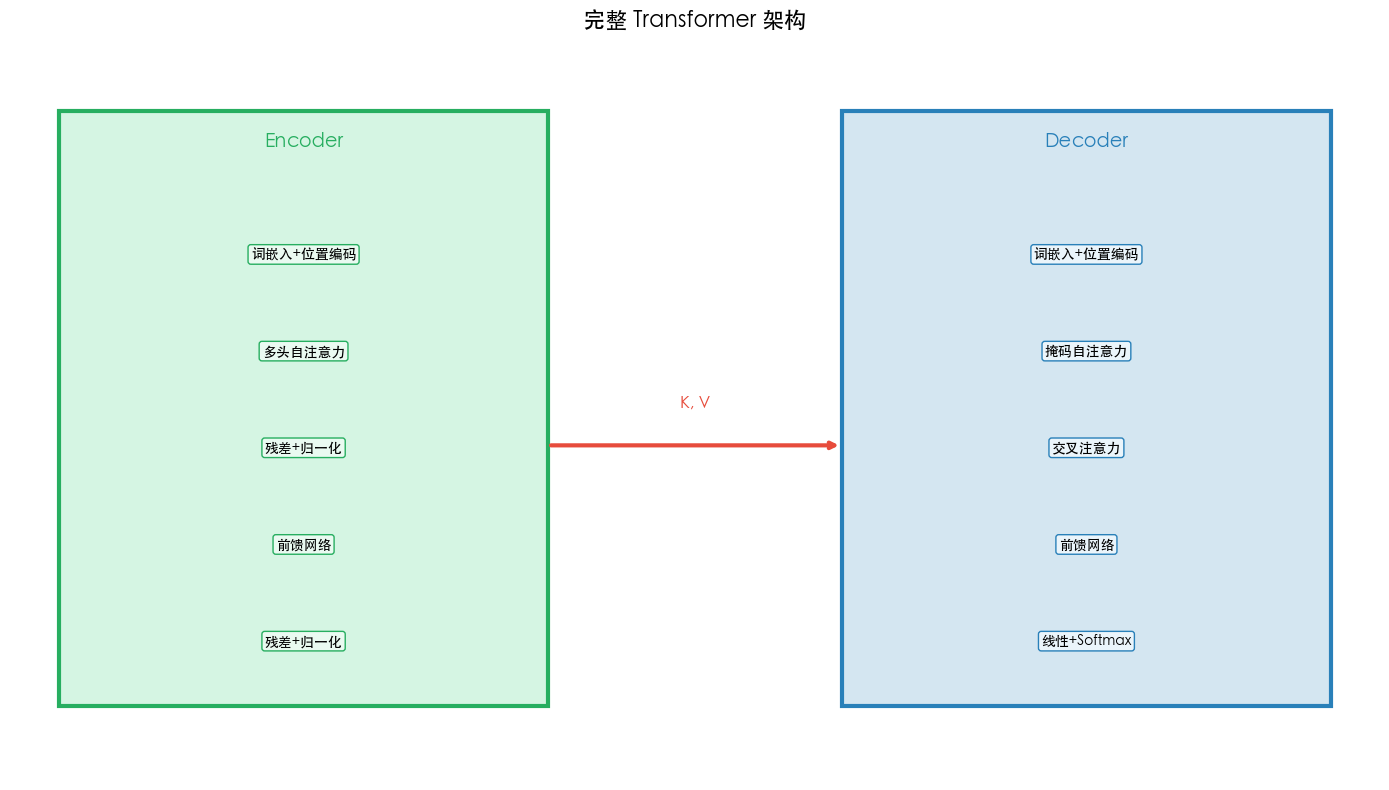</p>*完整 Transformer 架构图*

## 3. 代码实验室：完整 Transformer

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 完整 Transformer

In [ ]:
class PositionalEncoding(nn.Module):    def __init__(self, d_model, max_len=100):        super().__init__()        PE = torch.zeros(max_len, d_model)        position = torch.arange(max_len).unsqueeze(1).float()        div_term = torch.exp(torch.arange(0, d_model, 2).float() *                            -(np.log(10000.0) / d_model))        PE[:, 0::2] = torch.sin(position * div_term)        PE[:, 1::2] = torch.cos(position * div_term)        self.register_buffer('PE', PE.unsqueeze(0))    def forward(self, x):        return x + self.PE[:, :x.size(1)]class Transformer(nn.Module):    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64,                 n_heads=4, d_ff=256, n_layers=2, max_len=50):        super().__init__()        self.d_model = d_model        self.src_embed = nn.Embedding(src_vocab_size, d_model)        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model)        self.pos_enc = PositionalEncoding(d_model, max_len)        self.encoder_layers = nn.ModuleList([            nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout=0.1,                                       batch_first=True)            for _ in range(n_layers)        ])        self.decoder_layers = nn.ModuleList([            nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.1,                                       batch_first=True)            for _ in range(n_layers)        ])        self.fc_out = nn.Linear(d_model, tgt_vocab_size)    def encode(self, src):        x = self.pos_enc(self.src_embed(src))        for layer in self.encoder_layers:            x = layer(x)        return x    def decode(self, tgt, enc_output, causal_mask):        x = self.pos_enc(self.tgt_embed(tgt))        for layer in self.decoder_layers:            x = layer(x, enc_output, tgt_mask=causal_mask)        return self.fc_out(x)    def forward(self, src, tgt, causal_mask=None):        enc_output = self.encode(src)        if causal_mask is None:            S = tgt.size(1)            causal_mask = nn.Transformer.generate_square_subsequent_mask(S)        output = self.decode(tgt, enc_output, causal_mask)        return output

### 3.2 构建迷你翻译任务

In [ ]:
src_vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2,             'I': 3, 'love': 4, 'like': 5, 'cats': 6, 'dogs': 7,             'deep': 8, 'learning': 9, 'He': 10, 'She': 11,             'likes': 12, 'music': 13, 'coding': 14}tgt_vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2,             '我': 3, '爱': 4, '喜欢': 5, '猫': 6, '狗': 7,             '深度': 8, '学习': 9, '他': 10, '她': 11,             '音乐': 12, '编程': 13}pairs = [    ([3, 4, 6], [3, 4, 6]),    ([3, 4, 7], [3, 4, 7]),    ([3, 5, 8, 9], [3, 5, 8, 9]),    ([10, 12, 13], [10, 5, 12]),    ([11, 4, 14], [11, 4, 13]),    ([3, 5, 7], [3, 5, 7]),    ([10, 5, 13], [10, 5, 12]),    ([11, 5, 6], [11, 5, 6]),]src_idx2word = {v: k for k, v in src_vocab.items()}tgt_idx2word = {v: k for k, v in tgt_vocab.items()}max_len = 8def prepare_batch(pairs, max_len):    src_batch, tgt_batch = [], []    for src, tgt in pairs:        src_pad = src + [0] * (max_len - len(src))        tgt_in = [1] + tgt + [2]        tgt_in = tgt_in + [0] * (max_len + 2 - len(tgt_in))        src_batch.append(src_pad)        tgt_batch.append(tgt_in)    return torch.tensor(src_batch), torch.tensor(tgt_batch)src_tensor, tgt_tensor = prepare_batch(pairs, max_len)print(f"源: {src_tensor.shape}, 目标: {tgt_tensor.shape}")

### 3.3 训练

In [ ]:
model = Transformer(    src_vocab_size=len(src_vocab),    tgt_vocab_size=len(tgt_vocab),    d_model=64, n_heads=4, d_ff=256, n_layers=2)optimizer = torch.optim.Adam(model.parameters(), lr=0.001)loss_fn = nn.CrossEntropyLoss(ignore_index=0)losses = []for epoch in range(300):    causal_mask = nn.Transformer.generate_square_subsequent_mask(tgt_tensor.size(1))    output = model(src_tensor, tgt_tensor, causal_mask)    target = tgt_tensor[:, 1:]    pred = output[:, :-1, :]    loss = loss_fn(pred.reshape(-1, len(tgt_vocab)), target.reshape(-1))    optimizer.zero_grad()    loss.backward()    nn.utils.clip_grad_norm_(model.parameters(), 1.0)    optimizer.step()    losses.append(loss.item())    if (epoch + 1) % 50 == 0:        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

### 3.4 可视化训练

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(losses, color='#9b59b6', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Loss', fontsize=12)ax.set_title('Transformer 翻译模型训练损失', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 今日结语今天我们搭建了完整的 Transformer：Encoder 理解源语言，Decoder 生成目标语言，交叉注意力连接两者。Transformer 的核心思想：**用注意力替代循环，用并行替代串行**。这让训练速度大幅提升，也开启了 GPT、BERT 等大模型的时代。明天，我们将学习 Transformer 的两种重要变体：Encoder-only（BERT）和 Decoder-only（GPT）。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 完整的翻译流程 | Transformer 架构 || 理解源语言 | Encoder 编码 || 生成目标语言 | Decoder 解码 || 翻译时参考原文 | 交叉注意力 || 一个一个词生成 | 自回归生成 || 用注意力替代循环 | Transformer 的核心创新 |